In [75]:
os.getcwd()
os.chdir('/Users/ashleypritchard/Desktop/APHL/Results')
os.getcwd()

'/Users/ashleypritchard/Desktop/APHL/Results'

In [89]:
import pandas as pd
import os

#!/Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12 -m pip install rapidfuzz
#!pip install rapidfuzz
from rapidfuzz import fuzz
# Install pandas and openpyxl using pip
#!pip install pandas openpyxl
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## LLM Metadata extraction preliminary results

In [77]:
MISSING = {
    "", "na", "n/a", "nan", "none", "null",
    "not provided", "not available", "missing",
    "unavailable", "unavailable, not provided"
}

def normalize(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    return None if s in MISSING else s

def is_missing(x):
    return x is None or pd.isna(x)

def fuzzy_score(gt_val, pred_val):
    if is_missing(gt_val) or is_missing(pred_val):
        return None
    return fuzz.token_sort_ratio(str(gt_val), str(pred_val))

def compare_with_fuzzy(gt_val, pred_val, threshold=60):
    gt_missing = is_missing(gt_val)
    pred_missing = is_missing(pred_val)

    if gt_missing and pred_missing:
        return "TN"
    if gt_missing and not pred_missing:
        return "FP"
    if not gt_missing and pred_missing:
        return "FN"

    score = fuzz.token_sort_ratio(str(gt_val), str(pred_val))
    return "TP" if score >= threshold else "FP"

def evaluate_metadata(
    gt_df,
    pred_df,
    key="RepresentativeSelection.BioSample.accession",
    threshold=50,
    exclude_cols=("RepresentativeSelection.BioProject.accession",)
):
    gt2 = gt_df.rename(columns={key: key + "_gt"})
    pred2 = pred_df.rename(columns={key: key + "_pred"})

    comp = gt2.merge(
        pred2,
        left_on=key + "_gt",
        right_on=key + "_pred",
        how="inner",
        suffixes=("_gt", "_pred"),
        validate="one_to_one"
    )

    compare_cols = [
        c for c in gt_df.columns
        if c not in exclude_cols and c != key and c in pred_df.columns
    ]

    records = []
    biosample_col = key + "_gt"

    for _, row in comp.iterrows():
        biosample = row[biosample_col]

        for col in compare_cols:
            gt_val = normalize(row[f"{col}_gt"])
            pred_val = normalize(row[f"{col}_pred"])

            score = fuzzy_score(gt_val, pred_val)
            label = compare_with_fuzzy(gt_val, pred_val, threshold=threshold)

            records.append({
                "biosample_accession": biosample,
                "column": col,
                "gt_value": gt_val,
                "pred_value": pred_val,
                "fuzzy_score": score,
                "label": label
            })

    df_eval = pd.DataFrame(records)

    cm_counts = df_eval["label"].value_counts().reindex(["TP", "FP", "TN", "FN"], fill_value=0)

    y_true, y_pred = [], []
    for label in df_eval["label"]:
        if label == "TP":
            y_true.append(1); y_pred.append(1)
        elif label == "TN":
            y_true.append(0); y_pred.append(0)
        elif label == "FP":
            y_true.append(0); y_pred.append(1)
        elif label == "FN":
            y_true.append(1); y_pred.append(0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    mean_fuzzy_score = df_eval["fuzzy_score"].dropna().mean()

    FP = cm_counts["FP"]
    TN = cm_counts["TN"]

    hallucination_rate = FP / (FP + TN) if (FP + TN) > 0 else 0


    cm_df = pd.DataFrame(
        cm,
        index=["GT Missing", "GT Present"],
        columns=["Pred Missing", "Pred Present"]
    )

    metrics = {
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_fuzzy_score": mean_fuzzy_score,
        "Hallucination Rate": hallucination_rate
    }

    return df_eval, cm_counts, cm_df, metrics

def plot_confusion_matrix(cm_df, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("Ground Truth")
    plt.xlabel("Prediction")
    plt.show()

#### The metadata in this format took me 1 hour 7 minutes to complete. 

## Attempt 1

Attempt one:  I used the following prompt "“​​Extract the metadata for the following attributes from this bioproject record (PRJNA493622) along with these associated biosamples   (SAMN30593874 SAMN30593875 SAMN30593876 SAMN30593877 SAMN30593878 SAMN30593879 SAMN30593880 SAMN30593881 SAMN30593882 SAMN30593883): *xml format attributes*   Export as a CSV with the name “*c_auris_1.csv” If there is anything that you are unable to find, please enter "not provided".

Chat automatically started looking for a paper and found one and said that the biosample xml is not used in the paper (big surprise!)  
Took 1 min 46 seconds haha jk that only included 50 columns.  
2 minuts and 32 seconds to produce the full csv jk again, it added 100 columns  
40 seconds, finally correct

Notes: Must specify to search through the XML or it will remove a lot of columns. Chat has difficulties with the number of columns (need to either provide a csv of just the column headers or need to decrease the number of columns)

In [80]:
gt

,RepresentativeSelection.BioSample.id,RepresentativeSelection.BioSample.accession,RepresentativeSelection.BioProject.accession,BioSample.@id,BioSample.@accession,BioProject.Project.ProjectID.ArchiveID.@accession,BioProject.Project.ProjectID.ArchiveID.@id,BioProject.Project.ProjectDescr.Description,BioProject.Project.ProjectDescr.ExternalLink.@label,BioProject.Project.ProjectDescr.ExternalLink.URL,...,Library strategy,Library Source,Library Selection,Library Layout,Umberella Project accession ID,Associated Bioprojects (if its an umberella ),Reference Genome Genebank ID,Reference genome RefSeq ID,Genebank ID,Data Storage Provider
0,30593874,SAMN30593874,PRJNA493622,30593874,SAMN30593874,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
1,30593875,SAMN30593875,PRJNA493622,30593875,SAMN30593875,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
2,30593876,SAMN30593876,PRJNA493622,30593876,SAMN30593876,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
3,30593877,SAMN30593877,PRJNA493622,30593877,SAMN30593877,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
4,30593878,SAMN30593878,PRJNA493622,30593878,SAMN30593878,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
5,30593879,SAMN30593879,PRJNA493622,30593879,SAMN30593879,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
6,30593880,SAMN30593880,PRJNA493622,30593880,SAMN30593880,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
7,30593881,SAMN30593881,PRJNA493622,30593881,SAMN30593881,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
8,30593882,SAMN30593882,PRJNA493622,30593882,SAMN30593882,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"
9,30593883,SAMN30593883,PRJNA493622,30593883,SAMN30593883,PRJNA493622,493622,Multiple introductions and subsequent transmis...,NaN,NaN,...,WGS,Genoimc,Random,Paired,NaN,NaN,NaN,NaN,NaN,"GS, NCBI, S3"


label
TP     325
FP     102
TN    3970
FN    6643
Name: count, dtype: int64
{'TN': 3970, 'FP': 102, 'FN': 6643, 'TP': 325, 'accuracy': 0.38903985507246375, 'precision': 0.7611241217798594, 'recall': 0.04664179104477612, 'f1': 0.0878972278566599, 'mean_fuzzy_score': 84.2687208317577, 'Hallucination Rate': 0.02504911591355599}


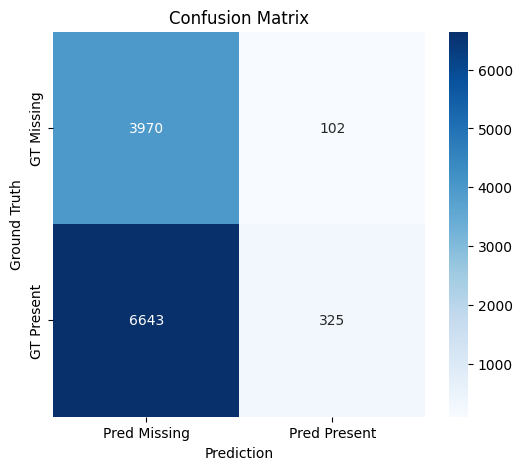

In [79]:
gt = pd.read_csv("ground truth - Sheet1.csv")
pred = pd.read_excel("c_auris_1_exact_v3.xlsx")

df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=pred,
    key="RepresentativeSelection.BioSample.accession",
    threshold=50
)

print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)

## Attempt 2

Attempt two: I used the following prompt "Extract the metadata for the following attributes, obtained from the excel sheet "names.xlsx" from this bioproject record (PRJNA493622) along with these associated biosamples (SAMN30593874 SAMN30593875 SAMN30593876 SAMN30593877 SAMN30593878 SAMN30593879 SAMN30593880 SAMN30593881 SAMN30593882 SAMN30593883). Please Use all of the columns and any information that you cannot find please fill in the cell with "Not provided". You are welcome to use any sources including bioproject, biosample, ncbi taxonomy, SRA, etc. Please search through the XML however, if you are confident that metadata is present but does not match the exact xlm format is correct you may include that. Once you are completed please export the table as a csv with the name "c_auris_2.csv" Along with an atteched excel file of the column headers.  

1 minute 53 seconds - forgot the added columns at the end
2 minutes 40 seconds

Notes: Make sure to specificy not to forget any columns!!

label
TP     216
FP     102
TN    3980
FN    6742
Name: count, dtype: int64
{'TN': 3980, 'FP': 102, 'FN': 6742, 'TP': 216, 'accuracy': 0.38007246376811593, 'precision': 0.6792452830188679, 'recall': 0.031043403276803678, 'f1': 0.05937328202308961, 'mean_fuzzy_score': 82.55308561328778, 'Hallucination Rate': 0.024987751102400785}


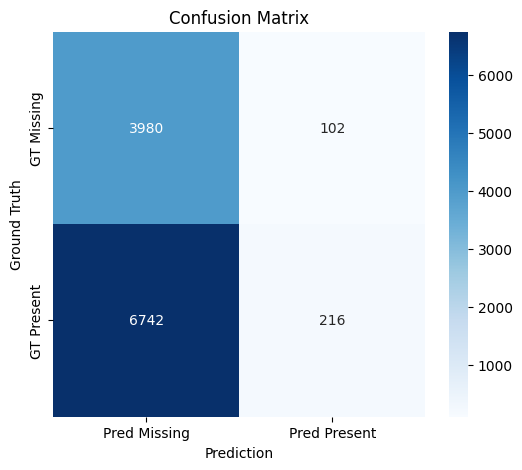

In [50]:
c_auris_2 = pd.read_excel('c_auris_2_fixed2.xlsx')
c_auris_2

df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=c_auris_2,
    key="RepresentativeSelection.BioSample.accession",
    threshold=50
)

print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)

## Attempt 3

Attempt 3:  
Prompt: You are an expert NCBI BioProject/BioSample metadata curator. Your goal is to produce a complete, accurate metadata table that minimizes manual curation time.

Task:
Extract metadata for BioProject PRJNA493622 and the following 10 BioSamples:
- SAMN30593874
- SAMN30593875
- SAMN30593876
- SAMN30593877
- SAMN30593878
- SAMN30593879
- SAMN30593880
- SAMN30593881
- SAMN30593882
- SAMN30593883

Required columns: Use EXACTLY the column headers from the uploaded file "names.xlsx" (first row). Do not add, remove, or reorder any columns. Every row must contain a value for EVERY column.

Sources (search in this order and parse ALL available data):
1. Official NCBI BioProject page: https://www.ncbi.nlm.nih.gov/bioproject/PRJNA493622
2. Each individual BioSample page (e.g., https://www.ncbi.nlm.nih.gov/biosample/SAMN30593874)
3. Linked SRA experiments/runs and Run Selector
4. NCBI Taxonomy entries
5. Any descriptive text, attribute tables, free-text fields, or linked publications on the pages above

You MUST extract from HTML attribute tables, free-text descriptions, and any unstructured content — do NOT limit yourself to XML. If the exact value appears in any visible field or text, use it. If the same field has conflicting values, choose the most specific/official NCBI value and note the source briefly in your thinking.

For any field where no information is found after thorough search, use exactly: "Not provided"

Instructions:
Think step by step:
1. List every column header from names.xlsx.
2. For each of the 10 BioSamples, visit the relevant NCBI pages (in your knowledge or via browsing if available) and extract the value for every single column.
3. Fill "Not provided" only when truly absent.

Output format (exactly in this order):

A. First, a clean Markdown table with the column headers as the first row, followed by exactly 10 data rows (one per BioSample). This is for easy human review and comparison with the gold standard.

B. Then, output the COMPLETE CSV content inside a single code block labeled 
csv. The CSV must include the exact headers from names.xlsx and exactly 10 rows. It must be valid CSV that can be copied and saved directly as "c_auris_3.csv". Use double quotes around any field that contains commas.

Do not omit any column. Do not summarize or shorten the output. Be maximally complete and accurate."  
  
4 Minutes 9 seconds

label
TP     298
FP     170
TN    3949
FN    6623
Name: count, dtype: int64
{'TN': 3949, 'FP': 170, 'FN': 6623, 'TP': 298, 'accuracy': 0.38469202898550725, 'precision': 0.6367521367521367, 'recall': 0.04305736165294033, 'f1': 0.08066044119637299, 'mean_fuzzy_score': 82.27821691455578, 'Hallucination Rate': 0.04127215343529983}


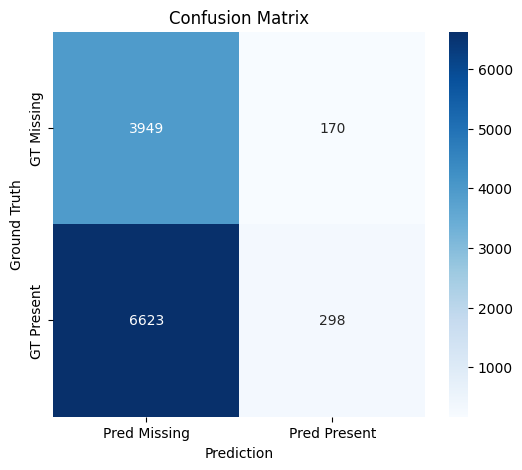

In [51]:
c_auris_3 = pd.read_excel('c_auris_3.xlsx')
c_auris_2

df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=c_auris_3,
    key="RepresentativeSelection.BioSample.accession",
    threshold=60
)

print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)

## Different format of metadata

#### The metadata in this format, of course I did not make a note for C. auris but for the others of a similar format took me on average 30 minutes. However I did add some columns obtained from the previous format so I would assume that from scratch, this would take me 45 minutes to complete

In [99]:
MISSING = {
    "", "na", "n/a", "nan", "none", "null",
    "not provided", "not available", "missing",
    "unavailable", "unavailable, not provided", "Not Collected", "not collected"
}

def normalize(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    return None if s in MISSING else s

def is_missing(x):
    return x is None or pd.isna(x)

def fuzzy_score(gt_val, pred_val):
    if is_missing(gt_val) or is_missing(pred_val):
        return None
    return fuzz.token_sort_ratio(str(gt_val), str(pred_val))

def compare_with_fuzzy(gt_val, pred_val, threshold=60):
    gt_missing = is_missing(gt_val)
    pred_missing = is_missing(pred_val)

    if gt_missing and pred_missing:
        return "TN"
    if gt_missing and not pred_missing:
        return "FP"
    if not gt_missing and pred_missing:
        return "FN"

    score = fuzz.token_sort_ratio(str(gt_val), str(pred_val))
    return "TP" if score >= threshold else "FP"

def fix_headers(df):
    rename_map = {
        "Submitter Instituition": "Submitter Institution",
        "Geographoc Location": "Geographic Location",
        "Umberella Project accession ID": "Umbrella Project accession ID",
        "Isolation source ": "Isolation source",
    }
    df = df.copy()
    df.columns = [rename_map.get(c, c) for c in df.columns]
    return df

def evaluate_metadata(
    gt_df,
    pred_df,
    key="Biosample",
    threshold=100,
    exclude_cols=None
):
    gt_df = fix_headers(gt_df)
    pred_df = fix_headers(pred_df)

    if exclude_cols is None:
        exclude_cols = {
            key,
            "Bioproject Accession (accession or ProjectID??)",
            "Taxonomy ID",
            "Registration Date",
            "Biosample Submission Date",
            "SRR Published date",
            "SRA Normalized Date",
            "SRA Lite date created",
            "Fastq date create",
        }

    gt2 = gt_df.rename(columns={key: key + "_gt"})
    pred2 = pred_df.rename(columns={key: key + "_pred"})

    comp = gt2.merge(
        pred2,
        left_on=key + "_gt",
        right_on=key + "_pred",
        how="inner",
        suffixes=("_gt", "_pred"),
        validate="one_to_one"
    )

    compare_cols = [
        c for c in gt_df.columns
        if c not in exclude_cols and c in pred_df.columns
    ]

    records = []
    for _, row in comp.iterrows():
        for col in compare_cols:
            gt_val = normalize(row[f"{col}_gt"])
            pred_val = normalize(row[f"{col}_pred"])
            score = fuzzy_score(gt_val, pred_val)
            label = compare_with_fuzzy(gt_val, pred_val, threshold=threshold)

            records.append({
                "biosample_accession": row[f"{key}_gt"],
                "column": col,
                "gt_value": gt_val,
                "pred_value": pred_val,
                "fuzzy_score": score,
                "label": label
            })

    df_eval = pd.DataFrame(records)

    cm_counts = df_eval["label"].value_counts().reindex(["TP", "FP", "TN", "FN"], fill_value=0)

    y_true, y_pred = [], []
    for label in df_eval["label"]:
        if label == "TP":
            y_true.append(1); y_pred.append(1)
        elif label == "TN":
            y_true.append(0); y_pred.append(0)
        elif label == "FP":
            y_true.append(0); y_pred.append(1)
        elif label == "FN":
            y_true.append(1); y_pred.append(0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0
    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

    FP = cm_counts["FP"]
    TN = cm_counts["TN"]

    hallucination_rate = FP / (FP + TN) if (FP + TN) > 0 else 0

    cm_df = pd.DataFrame(
        cm,
        index=["GT Missing", "GT Present"],
        columns=["Pred Missing", "Pred Present"]
    )

    metrics = {
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_fuzzy_score": df_eval["fuzzy_score"].dropna().mean(),
        "Hallucination Rate": hallucination_rate
    }

    return df_eval, cm_counts, cm_df, metrics

def plot_confusion_matrix(cm_df):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.ylabel("Ground Truth")
    plt.xlabel("Prediction")
    plt.show()

## Attempt 4

Attempt 4: Same prompt as above, however I used a different format of metadata.  
3 minutes 25 seconds

{'TP': 179, 'FP': 70, 'TN': 91, 'FN': 30, 'accuracy': 0.7297297297297297, 'precision': 0.7188755020080321, 'recall': 0.8564593301435407, 'f1': 0.7816593886462881, 'mean_fuzzy_score': 98.46390168970815, 'Hallucination Rate': 0.43478260869565216}


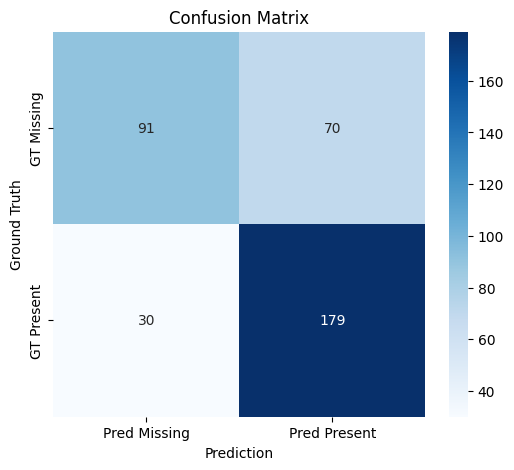

In [94]:
gt = pd.read_csv("ashley gt - Sheet1.csv")
pred = pd.read_excel("c_auris_4.xlsx")

df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=pred,
    key="Biosample",
    threshold=100
)

#print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)

In [82]:
gt

,Bioproject Accession (accession or ProjectID??),Taxonomy ID,Registration Date,Submitter Instituition,Biosample,Collection Date,Organism,Isolate,Strain,Collected by,...,SRA Lite date created,Fastq date create,GISAID virus name (gisaid_virus_name),Sequenced by,Umberella Project accession ID,Associated Bioprojects (if its an umberella ),Reference Genome Genebank ID,Reference genome RefSeq ID,Genebank ID,Data Storage Provider
0,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593883,2021-03,Candidozyma auris,USA/NY-WCPHL-CA-033735/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
1,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593882,2021-03,Candidozyma auris,USA/NY-WCPHL-CA-037025/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
2,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593881,2021-03,Candidozyma auris,USA/NY-WCPHL-CA-030319/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
3,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593880,2021-03,Candidozyma auris,USA/NY-WCPHL-CA-029028/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
4,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593879,2021-01,Candidozyma auris,USA/NY-WCPHL-CA-017132/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
5,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593878,2021-01,Candidozyma auris,USA/NY-WCPHL-CA-017131/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
6,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593877,2021-01,Candidozyma auris,USA/NY-WCPHL-CA-017125/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
7,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593876,2021-01,Candidozyma auris,USA/NY-WCPHL-CA-010626/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
8,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593875,2021-01,Candidozyma auris,USA/NY-WCPHL-CA-012530/2021,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"
9,PRJNA493622,498019,2018-09-27,National Center for Emerging and Zoonotic Infe...,SAMN30593874,2020-11,Candidozyma auris,USA/NY-WCPHL-CA-283079/2020,NaN,USA,...,NaN,NaN,NaN,NaN,PRJNA642852,NaN,GCA_003013715.2,NaN,642852[BioProject],"GS, NCBI, S3"


## Attempt 5

Attempt 5:  
Prompt: You are an expert NCBI BioProject/BioSample metadata curator specializing in pathogen sequence data (e.g., Candida auris). Your goal is to produce complete, accurate, publication-ready metadata that minimizes manual curation time to near zero.

Task: Extract metadata for BioProject PRJNA493622 and exactly these 10 BioSamples:
SAMN30593874
SAMN30593875
SAMN30593876
SAMN30593877
SAMN30593878
SAMN30593879
SAMN30593880
SAMN30593881
SAMN30593882
SAMN30593883

Exact column headers (use these verbatim — do not change spelling, order, or capitalization, even if they contain typos):
Bioproject Accession (accession or ProjectID??),Taxonomy ID,Registration Date,Submitter Instituition,Biosample,Collection Date,Organism,Isolate,Strain,Collected by,Collection Date,Geographoc Location,Host,Host subject id,Host disease,Isolation source ,Body part,Host Age,Host sex,Anatomical part,Latitude/Longitude,Serotype/Subtype,Biosample Submission Date,Sequencing platform,Experiment,External ID,SRR,SRP,Design,Library Name,Library strategy,Library Source,Library Selection,Library Layout,SRR Published date,SRA Normalized Date,SRA Lite date created,Fastq date create,GISAID virus name (gisaid_virus_name),Sequenced by,Umberella Project accession ID,Associated Bioprojects (if its an umberella ),Reference Genome Genebank ID,Reference genome RefSeq ID,Genebank ID,Data Storage Provider

Bioproject Accession (accession or ProjectID??): PRJNA493622
Taxonomy ID: 498019
Registration Date: 27-Sep-2018
Submitter Instituition: National Center for Emerging and Zoonotic Infectious Diseases- Mycotic Diseases Branch
Biosample: SAMN30593874
Collection Date: 2020-11
Organism: Candidozyma auris
Isolate: Not provided
Strain: USA/NY-WCPHL-CA-283079/2020
Collected by: USA
Collection Date: Not provided   ← (second Collection Date column)
Geographoc Location: USA:Northeast
Host: Homo sapiens
Host subject id: Not provided
Host disease: not collected
Isolation source : sputum
Body part: Not provided
Host Age: Not provided
Host sex: Not provided
Anatomical part: Not provided
Latitude/Longitude: 40.730610 N 73.935242 W
Serotype/Subtype: Not provided
Biosample Submission Date: 2022-08-30
Sequencing platform: Not provided
Experiment: Not provided
External ID: Not provided
SRR: Not provided
SRP: Not provided
Design: Not provided
Library Name: Not provided
Library strategy: Not provided
Library Source: Not provided
Library Selection: Not provided
Library Layout: Not provided
SRR Published date: Not provided
SRA Normalized Date: Not provided
SRA Lite date created: Not provided
Fastq date create: Not provided
GISAID virus name (gisaid_virus_name): Not provided
Sequenced by: Not provided
Umberella Project accession ID: 642852
Associated Bioprojects (if its an umberella ): 33 additional projects are components of the Candida auris umbrella project
Reference Genome Genebank ID: Not provided
Reference genome RefSeq ID: Not provided
Genebank ID: Not provided
Data Storage Provider: Not provided


Sources (search in this exact order and parse ALL visible content):
1. Official BioProject page: https://www.ncbi.nlm.nih.gov/bioproject/PRJNA493622
2. Each individual BioSample page: https://www.ncbi.nlm.nih.gov/biosample/[SAMN ID]
3. All linked SRA Experiments/Runs and Run Selector tables
4. NCBI Taxonomy pages
5. Any attribute tables, free-text descriptions, publications, or unstructured fields on the pages above

You MUST use your browse_page (or equivalent web-browsing) tool to fetch the latest HTML content for every URL above. Parse attribute tables, free-text, and hidden fields verbatim. Never rely solely on internal knowledge.

After completing all 10 samples:
- Perform self-critique: "Review every cell for accuracy against the source pages. Fix any errors."
- Output exactly this format (nothing else before or after):

A. Clean Markdown table (headers + exactly 10 data rows) for human review.

B. Then, inside a single code block labeled ```csv
   the COMPLETE valid CSV content (exact headers + 10 rows). Use double quotes around any field containing commas. This CSV must be copy-paste ready as "c_auris_4.csv".

2 minutes 16 seconds

{'TP': 159, 'FP': 60, 'TN': 111, 'FN': 40, 'accuracy': 0.7297297297297297, 'precision': 0.726027397260274, 'recall': 0.7989949748743719, 'f1': 0.7607655502392344, 'mean_fuzzy_score': 96.7349707949498, 'Hallucination Rate': 0.3508771929824561}


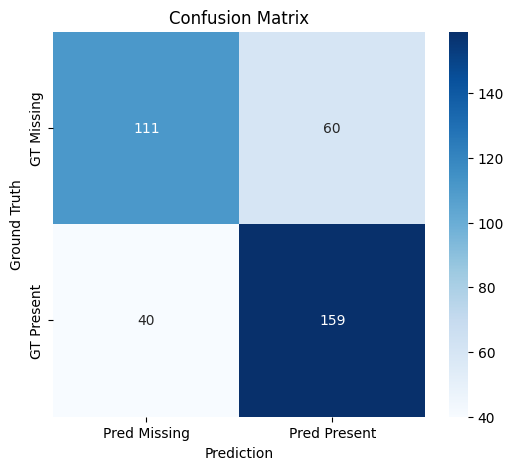

In [95]:
pred_1 = pd.read_csv("c_auris_5.csv")

df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=pred_1,
    key="Biosample",
    threshold=100
)

#print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)

## Attempt 6

Attempt 6:  
prompt: You are an expert NCBI BioProject/BioSample metadata curator specializing in pathogen sequence data (e.g., Candida auris). Your goal is to produce complete, accurate, publication-ready metadata that minimizes manual curation time to near zero.

Task: Extract metadata for BioProject PRJNA493622 and exactly this BioSample: SAMN30593874.

Exact column headers (use these verbatim — do not change spelling, order, or capitalization, even if they contain typos): Bioproject Accession (accession or ProjectID??),Taxonomy ID,Registration Date,Submitter Instituition,Biosample,Collection Date,Organism,Isolate,Strain,Collected by,Collection Date,Geographoc Location,Host,Host subject id,Host disease,Isolation source ,Body part,Host Age,Host sex,Anatomical part,Latitude/Longitude,Serotype/Subtype,Biosample Submission Date,Sequencing platform,Experiment,External ID,SRR,SRP,Design,Library Name,Library strategy,Library Source,Library Selection,Library Layout,SRR Published date,SRA Normalized Date,SRA Lite date created,Fastq date create,GISAID virus name (gisaid_virus_name),Sequenced by,Umberella Project accession ID,Associated Bioprojects (if its an umberella ),Reference Genome Genebank ID,Reference genome RefSeq ID,Genebank ID,Data Storage Provider

Bioproject Accession (accession or ProjectID??): PRJNA493622 Taxonomy ID: 498019 Registration Date: 27-Sep-2018 Submitter Instituition: National Center for Emerging and Zoonotic Infectious Diseases- Mycotic Diseases Branch Biosample: SAMN30593874 Collection Date: 2020-11 Organism: Candidozyma auris Isolate: Not provided Strain: USA/NY-WCPHL-CA-283079/2020 Collected by: USA Collection Date: Not provided ← (second Collection Date column) Geographoc Location: USA:Northeast Host: Homo sapiens Host subject id: Not provided Host disease: not collected Isolation source : sputum Body part: Not provided Host Age: Not provided Host sex: Not provided Anatomical part: Not provided Latitude/Longitude: 40.730610 N 73.935242 W Serotype/Subtype: Not provided Biosample Submission Date: 2022-08-30 Sequencing platform: Not provided Experiment: Not provided External ID: Not provided SRR: Not provided SRP: Not provided Design: Not provided Library Name: Not provided Library strategy: Not provided Library Source: Not provided Library Selection: Not provided Library Layout: Not provided SRR Published date: Not provided SRA Normalized Date: Not provided SRA Lite date created: Not provided Fastq date create: Not provided GISAID virus name (gisaid_virus_name): Not provided Sequenced by: Not provided Umberella Project accession ID: 642852 Associated Bioprojects (if its an umberella ): 33 additional projects are components of the Candida auris umbrella project Reference Genome Genebank ID: Not provided Reference genome RefSeq ID: Not provided Genebank ID: Not provided Data Storage Provider: Not provided

Sources (search in this exact order and parse ALL visible content):

Official BioProject page: https://www.ncbi.nlm.nih.gov/bioproject/PRJNA493622
Each individual BioSample page: https://www.ncbi.nlm.nih.gov/biosample/[SAMN ID]
All linked SRA Experiments/Runs and Run Selector tables
NCBI Taxonomy pages
Any attribute tables, free-text descriptions, publications, or unstructured fields on the pages above
You MUST use your browse_page (or equivalent web-browsing) tool to fetch the latest HTML content for every URL above. Parse attribute tables, free-text, and hidden fields verbatim. Never rely solely on internal knowledge.

Few-shot example (follow this exact style, formatting, and level of specificity):



Instructions: A. Perform self-critique: "Review every cell for accuracy against the source pages. Fix any errors." Output exactly this format (nothing else before or after) B. Export the file with the one biosample as a csv named ""c_auris_6_1.csv" Once you complete that, please repeat for the following biosamples: SAMN30593875 SAMN30593876 SAMN30593877 SAMN30593878 SAMN30593879 SAMN30593880 SAMN30593881 SAMN30593882 SAMN30593883 making sure to complete one before starting the next. for each iterative file it will still be "c-auris_6_x.csv" where x is the number of biosamples done. Example: the second file will be c-auris_6_2.csv. Once you are dome there should be 10 files for me to download

### The goal is to see if only completing one biosample at a time increases accuracy

2 minutes 46 seconds

In [61]:
import glob

file_pattern = "c_auris_6_*.csv"
files = sorted(glob.glob(file_pattern))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df.to_csv("c_auris_merged.csv", index=False)

print(f"Merged {len(files)} files into c_auris_merged.csv")

merged = pd.read_csv("c_auris_merged.csv")
merged

Merged 10 files into c_auris_merged.csv


,Bioproject Accession (accession or ProjectID??),Taxonomy ID,Registration Date,Submitter Instituition,Biosample,Collection Date,Organism,Isolate,Strain,Collected by,...,SRA Lite date created,Fastq date create,GISAID virus name (gisaid_virus_name),Sequenced by,Umberella Project accession ID,Associated Bioprojects (if its an umberella ),Reference Genome Genebank ID,Reference genome RefSeq ID,Genebank ID,Data Storage Provider
0,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593874,2020-11,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-283079/2020,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
1,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593883,2021-03,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-033735/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
2,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593875,2021-01,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-012530/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
3,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593876,2021-01,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-010626/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
4,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593877,2021-01,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-017125/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
5,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593878,2021-01,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-017131/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
6,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593879,2021-01,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-017132/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
7,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593880,2021-03,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-029028/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
8,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593881,2021-03,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-030319/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided
9,PRJNA493622,498019,27-Sep-2018,National Center for Emerging and Zoonotic Infe...,SAMN30593882,2021-03,Candidozyma auris,Not provided,USA/NY-WCPHL-CA-037025/2021,USA,...,Not provided,Not provided,Not provided,Wadsworth Center,642852,33 additional projects are components of the C...,Not provided,Not provided,Not provided,Not provided


In [100]:
df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=merged,
    key="Biosample",
    threshold=100
)

#print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)

KeyError: 'Biosample_gt'

Notes: Chat struggled a lot with 1100+ columns. I had to repeat requests for CSV downloads because it would leave out the added columns. Further prompt engineering would be needed in order to have to prevent multiple prompting and potentially decreasing accuracy. *I did not look into whether or not the files changed from download to download - I can do that and just remove the columns from the gt that were left out and see if changes occured. Possibly inflating or decreasing accuracy with the repeated "try again" asks. Overall it is very apparent that chat performs far better without the XML format of column names. However Additional testing with a greater number of columns in a human readable format is needed to determine if the lower number of columns for the formatting is the cause of better performance.  
  
Questions:  
1. Recommendations for prompting? Specifically with ensuring that the columns are all present if the XML format is the preferred format.
2. Within the XML formatted metadata, there are hundereds of columns that are essentially asking for all of the associated biosamples and their IDs, I do not think that chat understood that and I think it is leading to massive amounts of decreased accuracy. At what point is it worth removing something like that? Or do you think it would be a matter of formatting or prompting?
3. Fuzzy matching threshold?
4. Record time it takes to find mistakes and correct them?
5. I guess this has to do with my lack of understanding of CM... Does the order of the samples matter? Or does it just look at each biosample and compare the same biosamples to each other?
6. Is it possible to go overboard on the prompting? Do we want a short on consice prompt, or is few shot chain-of-thought okay?
  
Next Steps:
*figure out how to use chat api?? 
1. Ground truth -> Pick the format, adjust accordingly
2. Same prompt multiple times and compare outputs. Does the LLM put out different information each time even without changes to the prompt?
3. Once we find a prompt that works well, see how it does with multiple samples (2 bioproject, 20 total biosamples)



## Notes
Focus on the most important attributes (general attributes)
Measuring the metrics on attribute level for each attribute such as hallucination rather than just as a whole

What are the most important attributes that we want when searching? 
Relatively complete for an example demonstration. Limit the attributes to just the organism. pretty much the biosample

API 

# Final ground truth

Please extract the following metadata from the attached files: Bioproject Accession Biosample accession collected_by collection_date geo_loc_name host host_disease isolation_source lat_lon strain isolate culture_collection genotype host_age host_description host_disease_outcome host_disease_stage host_health_state host_sex host_subject_id host_tissue_sampled passage_history pathotype serotype serovar specimen_voucher subgroup subtype. Export as a single csv and input "Not Provided" if you cannot locate the information. Please use the HTML to fully extract the metadata Please record the time it takes to complete this  
  
34 seconds

{'TP': 79, 'FP': 0, 'TN': 191, 'FN': 0, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'mean_fuzzy_score': 100.0, 'Hallucination Rate': 0.0}


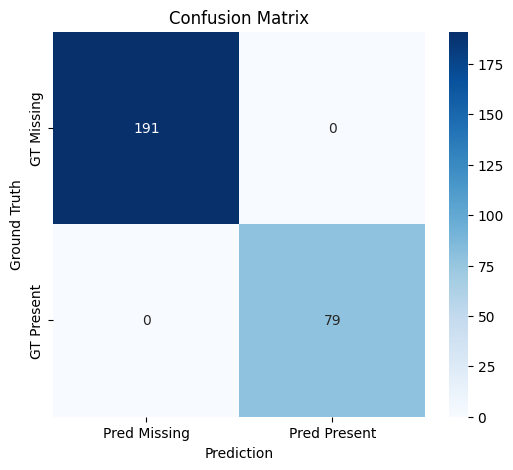

In [107]:
gt = pd.read_csv("package gt - Sheet1 (1).csv")
new_pred = pd.read_csv("biosample_metadata_extracted.csv")

df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=new_pred,
    key="Biosample accession",
    threshold=90
)

#print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)


## same as above, but rather than providing the HTML files, only giving it the Biosample accession

https://www.ncbi.nlm.nih.gov/bioproject/?term=PRJNA493622   
  
Please extract the following metadata from the list of biosamples: Bioproject Accession Biosample accession collected_by collection_date geo_loc_name host host_disease isolation_source lat_lon strain isolate culture_collection genotype host_age host_description host_disease_outcome host_disease_stage host_health_state host_sex host_subject_id host_tissue_sampled passage_history pathotype serotype serovar specimen_voucher subgroup subtype. Export as a single csv and input "Not Provided" if you cannot locate the information. Please fully extract the data from the webpage, use the attributes listed as column headers as these are the harmonized name. 
  
Bioproject: PRJNA493622   
Biosamples: SAMN30593883 SAMN30593882 SAMN30593881 SAMN30593880 SAMN30593879 SAMN30593878 SAMN30593877 SAMN30593876 SAMN30593875 SAMN30593874   
Please record the time it takes to complete this. Please perform a real and complete extraction  
  
1 minute 47 seconds

{'TP': 79, 'FP': 0, 'TN': 191, 'FN': 0, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'mean_fuzzy_score': 100.0, 'Hallucination Rate': 0.0}


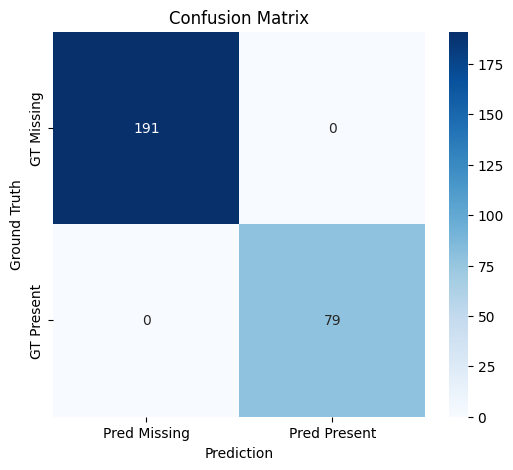

In [106]:
new_pred1 = pd.read_csv("PRJNA493622_biosample_metadata (2).csv")

df_eval, cm_counts, cm_df, metrics = evaluate_metadata(
    gt_df=gt,
    pred_df=new_pred1,
    key="Biosample accession",
    threshold=90
)

#print(cm_counts)
print(metrics)
plot_confusion_matrix(cm_df)

In [117]:
new_pred1

,Bioproject Accession,Biosample accession,collected_by,collection_date,geo_loc_name,host,host_disease,isolation_source,lat_lon,strain,...,host_sex,host_subject_id,host_tissue_sampled,passage_history,pathotype,serotype,serovar,specimen_voucher,subgroup,subtype
0,PRJNA493622,SAMN30593883,USA,2021-03,USA:Northeast,Homo sapiens,not collected,Not Provided,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-033735/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided
1,PRJNA493622,SAMN30593882,USA,2021-03,USA:Northeast,Homo sapiens,not collected,urine,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-037025/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
2,PRJNA493622,SAMN30593881,USA,2021-03,USA:Northeast,Homo sapiens,not collected,Nose,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-030319/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
3,PRJNA493622,SAMN30593880,USA,2021-03,USA:Northeast,Homo sapiens,not collected,blood,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-029028/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
4,PRJNA493622,SAMN30593879,USA,2021-01,USA:Northeast,Homo sapiens,not collected,Skin (Left Foot),40.730610 N 73.935242 W,USA/NY-WCPHL-CA-017132/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
5,PRJNA493622,SAMN30593878,USA,2021-01,USA:Northeast,Homo sapiens,not collected,urine,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-017131/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
6,PRJNA493622,SAMN30593877,USA,2021-01,USA:Northeast,Homo sapiens,not collected,Wound drainage,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-017125/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
7,PRJNA493622,SAMN30593876,USA,2021-01,USA:Northeast,Homo sapiens,not collected,urine,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-010626/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
8,PRJNA493622,SAMN30593875,USA,2021-01,USA:Northeast,Homo sapiens,not collected,blood,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-012530/2021,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN
9,PRJNA493622,SAMN30593874,USA,2020-11,USA:Northeast,Homo sapiens,not collected,sputum,40.730610 N 73.935242 W,USA/NY-WCPHL-CA-283079/2020,...,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,NaN


#Final Ground Truth

In [105]:
#for when I figure out the ch

import httpx
from pathlib import Path

biosample_ids = [
    "SAMN30593883",
    "SAMN30593884",
    "SAMN30593885"
]

base_url = "https://www.ncbi.nlm.nih.gov/biosample/?term={}"

for biosample_id in biosample_ids:
    url = base_url.format(biosample_id)
    
    response = httpx.get(url)
    response.raise_for_status()
    filename = f"{biosample_id}.html"
    Path(filename).write_text(response.text)
    
    print(f"Downloaded {biosample_id}")


Downloaded SAMN30593883
Downloaded SAMN30593884
Downloaded SAMN30593885


## % Coverage

In [108]:


coverage = gt.notna().mean() * 100

print(coverage)

Bioproject Accession    100.0
Biosample accession     100.0
collected_by            100.0
collection_date         100.0
geo_loc_name            100.0
host                    100.0
host_disease              0.0
isolation_source         90.0
lat_lon                 100.0
strain                  100.0
isolate                   0.0
culture_collection        0.0
genotype                  0.0
host_age                  0.0
host_description          0.0
host_disease_outcome      0.0
host_disease_stage        0.0
host_health_state         0.0
host_sex                  0.0
host_subject_id           0.0
host_tissue_sampled       0.0
passage_history           0.0
pathotype                 0.0
serotype                  0.0
serovar                   0.0
specimen_voucher          0.0
subgroup                  0.0
subtype                   0.0
dtype: float64


In [114]:
gt1 = pd.read_csv('fullPackage Attributes_Ashley - Sheet1 (1).csv')
coverage = gt1.notna().mean() * 100
coverage_df = coverage.reset_index()
coverage_df.columns = ['Attribute', 'Percent Coverage']
print(coverage_df)

               Attribute  Percent Coverage
0   Bioproject Accession        100.000000
1    Biosample accession        100.000000
2           collected_by         79.310345
3        collection_date         93.965517
4           geo_loc_name         99.137931
5                   host         95.689655
6           host_disease         72.413793
7       isolation_source         93.965517
8                lat_lon         30.172414
9                 strain         34.482759
10               isolate          0.000000
11    culture_collection          0.000000
12              genotype          0.000000
13              host_age          7.758621
14      host_description          0.000000
15  host_disease_outcome          0.000000
16    host_disease_stage          0.000000
17     host_health_state          0.000000
18              host_sex          6.034483
19       host_subject_id         15.517241
20   host_tissue_sampled          0.000000
21       passage_history          0.000000
22         